# 1. Setup & Environment
- 공간 데이터 처리 및 카토그래피 렌더링 라이브러리(GeoPandas, Matplotlib) 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 부호 환경 구성

In [1]:
# 1. 라이브러리 로드 및 환경 설정
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. Configuration & Unified Cartographic Palette
- 공간 경계 및 급증 원인 분해 산출물 디렉터리(`output/maps`) 설정
- Figure 5 세트(원인 분해 차트)와 일치하는 학술 팔레트 및 서울시 25개 자치구 코드 정의
  * 신규 공급형: Crimson Red (`#d73027`)
  * 공급+도로망 복합형: Slate Blue (`#33586b`)

In [2]:
# 2. 경로 및 지도 스타일 팔레트 정의
BASE_DIR = Path("/mnt/cowork/EV")
BOUNDARY_FP = BASE_DIR / "input/raw/집계구_2016/집계구.shp"
SPIKE_FP_MW = BASE_DIR / "output/spike_cause_decomposition_2021_2022_mw.csv"
SPIKE_FP_ORIG = BASE_DIR / "output/spike_cause_decomposition_2021_2022.csv"

DIR_MAPS = BASE_DIR / "output/maps"
DIR_MAPS.mkdir(parents=True, exist_ok=True)
OUT_PNG_MW = DIR_MAPS / "poster_spike_dong_minimap_mw.png"

# 서울시 25개 자치구 코드 매핑
GU_MAP = {
    "11010": "종로구", "11020": "중구", "11030": "용산구", "11040": "성동구", "11050": "광진구",
    "11060": "동대문구", "11070": "중랑구", "11080": "성북구", "11090": "강북구", "11100": "도봉구",
    "11110": "노원구", "11120": "은평구", "11130": "서대문구", "11140": "마포구", "11150": "양천구",
    "11160": "강서구", "11170": "구로구", "11180": "금천구", "11190": "영등포구", "11200": "동작구",
    "11210": "관악구", "11220": "서초구", "11230": "강남구", "11240": "송파구", "11250": "강동구",
}

# Figure 5 세트 일관 팔레트
COLOR_THEME = {
    "GU_FILL": "#f7f7f7",       # 자치구 기본 배경 폴리곤
    "GU_BORDER": "#999999",     # 자치구 경계선
    "SUPPLY": "#d73027",        # 신규 공급형 (Crimson Red)
    "MIXED": "#33586b",         # 공급+도로망 복합 (Slate Blue)
    "TEXT": "#222222",          # 주 라벨 텍스트
    "MUTED": "#666666",         # 부제 및 자치구 배경 라벨
}

print(f">> 출력 대상 인셋 맵 파일: {OUT_PNG_MW.name}")

>> 출력 대상 인셋 맵 파일: poster_spike_dong_minimap_mw.png


# 3. Spatial Boundary Extraction & Topology Cleanup
- 집계구 폴리곤을 자치구(`gu`) 및 행정동(`ADM_NM`) 단위로 각각 디졸브(Dissolve) 병합
- 미세 위상 틈새(Sliver polygon) 및 경계 노이즈 제거를 위한 양방향 버퍼 모폴로지 연산 적용

In [3]:
# 3. 공간 경계 로드 및 위상 정제
def load_gu_and_dong_boundaries(boundary_path: Path) -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """집계구 경계로부터 정제된 자치구 및 행정동 폴리곤 추출"""
    gdf = gpd.read_file(boundary_path)
    gdf = gdf.set_crs(epsg=5179, allow_override=True)
    gdf["TOT_REG_CD"] = gdf["TOT_REG_CD"].astype(str)
    
    gdf_seoul = gdf[gdf["TOT_REG_CD"].str.startswith("11")].copy()
    gdf_seoul["gu"] = gdf_seoul["TOT_REG_CD"].str[:5].map(GU_MAP)

    # 자치구 경계 디졸브 및 경계 정돈
    gdf_gu = gdf_seoul.dissolve(by="gu").reset_index()
    gdf_gu["geometry"] = gdf_gu.geometry.buffer(15).buffer(-15).simplify(20)

    # 행정동 단위 디졸브 및 미세 틈 제거
    gdf_dong = gdf_seoul.dissolve(by=["gu", "ADM_NM"]).reset_index()
    gdf_dong["geometry"] = gdf_dong.geometry.buffer(5).buffer(-5)
    
    return gdf_gu, gdf_dong

gdf_gu, gdf_dong = load_gu_and_dong_boundaries(BOUNDARY_FP)
print(f">> 공간 경계 정제 완료: {len(gdf_gu)}개 자치구 | {len(gdf_dong):,}개 행정동")

>> 공간 경계 정제 완료: 25개 자치구 | 424개 행정동


# 4. Spike Cause Data Loader & Spatial Feature Join
- 2021→2022 접근성 급증 요인 분해 산출물(`_mw.csv` 우선) 로드
- 접근성 변화폭($\Delta 2SFCA$) 기준 순위 부여 및 상위 10개 행정동 공간 결합 무결성 검증

In [4]:
# 4. 급증 요인 데이터 로드 및 공간 결합
fp_spike = SPIKE_FP_MW if SPIKE_FP_MW.exists() else SPIKE_FP_ORIG
if not fp_spike.exists():
    raise FileNotFoundError(f"원인 분해 산출물 CSV 파일이 누락되었습니다: {fp_spike}")

df_spike = pd.read_csv(fp_spike)
df_spike["rank"] = df_spike["delta_score"].rank(ascending=False).astype(int)

# 행정동 공간 결합 (gu + ADM_NM 기준)
gdf_spike_dong = gdf_dong.merge(
    df_spike, 
    left_on=["gu", "ADM_NM"], 
    right_on=["gu", "dong"], 
    how="inner"
)

n_matched = len(gdf_spike_dong)
print(f">> 상위 급증 동 매칭 완료: {n_matched} / 10개 행정동")

# 결합 누락 확인
missing = set(zip(df_spike["gu"], df_spike["dong"])) - set(zip(gdf_spike_dong["gu"], gdf_spike_dong["dong"]))
if missing:
    print(f"[!] 매칭 누락 발생: {missing}")

>> 상위 급증 동 매칭 완료: 10 / 10개 행정동


# 5. Minimap Cartographic Rendering with Leader Lines & High-Res Export
- 급증 상위 10개 행정동의 공간적 군집(마포, 강서·양천, 서초) 하이라이트 렌더링
- 밀집 지역 레이블 중첩 방지를 위한 리더라인(Leader line) 인출선 오프셋 배치
- 포스터 Figure 5 인셋용 고해상도(300 DPI) 이미지(`poster_spike_dong_minimap_mw.png`) 저장

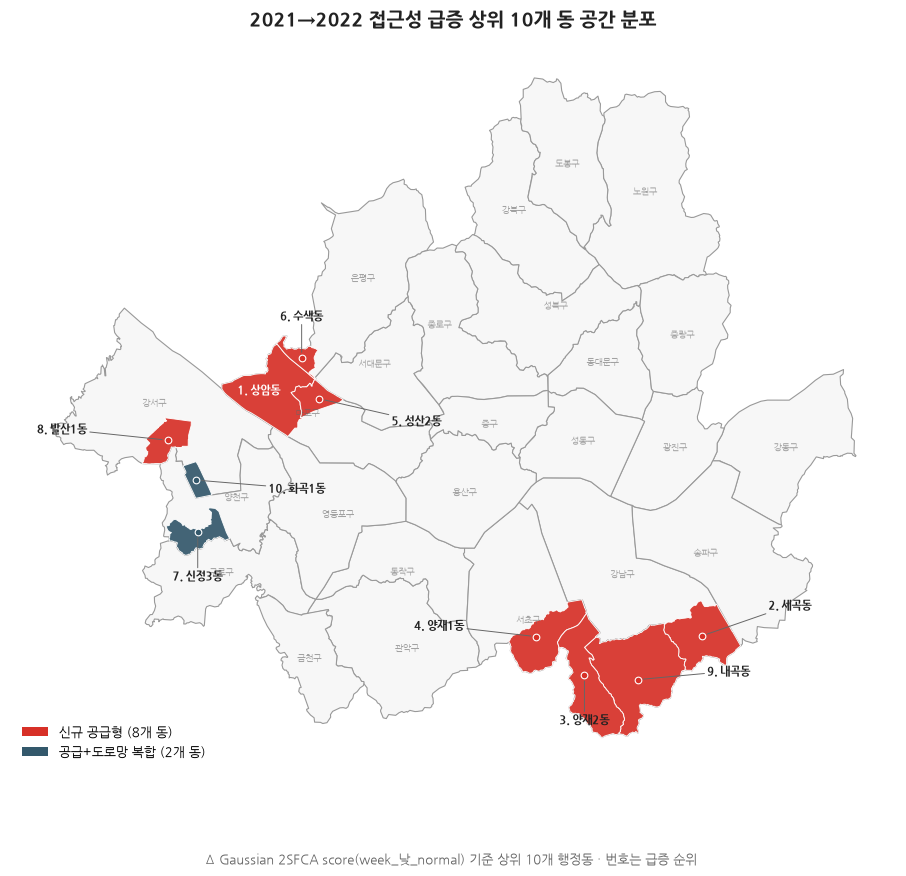

>> 포스터 Figure 5 인셋 미니맵 고해상도 저장 완료: /mnt/cowork/EV/output/maps/poster_spike_dong_minimap_mw.png


In [5]:
# 5. 미니맵 렌더링 및 내보내기
fig, ax = plt.subplots(figsize=(9.2, 9.8), facecolor="white")

# 1. 서울시 자치구 배경 경계 플롯
gdf_gu.plot(
    ax=ax, 
    color=COLOR_THEME["GU_FILL"], 
    edgecolor=COLOR_THEME["GU_BORDER"], 
    linewidth=0.8
)

# 2. 판정 유형별 급증 행정동 폴리곤 하이라이트
for verdict, color_key in [("신규 공급형", "SUPPLY"), ("공급+도로망 복합", "MIXED")]:
    sub = gdf_spike_dong[gdf_spike_dong["verdict"] == verdict]
    if len(sub) > 0:
        sub.plot(
            ax=ax, 
            color=COLOR_THEME[color_key], 
            edgecolor="white", 
            linewidth=0.7, 
            alpha=0.92
        )

# 3. 밀집 클러스터 행정동 라벨 리더라인(Leader Line) 오프셋 정의
LEADER_OFFSET = {
    "성산2동": (52, -16, "left"),
    "수색동": (0, 30, "center"),
    "발산1동": (-58, 8, "right"),
    "화곡1동": (52, -6, "left"),
    "신정3동": (0, -32, "center"),
    "양재1동": (-52, 8, "right"),
    "양재2동": (0, -32, "center"),
    "내곡동": (50, 6, "left"),
    "세곡동": (48, 22, "left"),
}

# 4. 행정동 명칭 및 순위 라벨링
for _, row in gdf_spike_dong.sort_values("rank").iterrows():
    c = row.geometry.representative_point()
    name = row["ADM_NM"]
    label = f"{row['rank']}. {name}"
    color = COLOR_THEME["SUPPLY"] if row["verdict"] == "신규 공급형" else COLOR_THEME["MIXED"]

    if name not in LEADER_OFFSET:
        # 폴리곤 면적이 충분한 행정동(상암동)은 내부 직접 표기
        ax.annotate(
            label, xy=(c.x, c.y), xytext=(0, 0), textcoords="offset points",
            fontsize=7.8, color="white", ha="center", va="center", fontweight="bold"
        )
        continue

    # 밀집 지역은 리더라인 인출선 적용
    dx, dy, ha = LEADER_OFFSET[name]
    ax.plot(c.x, c.y, "o", color=color, markersize=4.8, markeredgecolor="white", markeredgewidth=0.8, zorder=5)
    ax.annotate(
        label, xy=(c.x, c.y), xytext=(dx, dy), textcoords="offset points",
        fontsize=8, color=COLOR_THEME["TEXT"], ha=ha, va="center", fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=COLOR_THEME["MUTED"], lw=0.7, shrinkA=0, shrinkB=4),
        zorder=6,
    )

# 5. 자치구 명칭 워터마크 라벨링
for _, row in gdf_gu.iterrows():
    c = row.geometry.representative_point()
    ax.text(c.x, c.y, row["gu"], fontsize=6.5, color=COLOR_THEME["MUTED"], ha="center", va="center", alpha=0.6)

ax.set_axis_off()

# 헤더 및 범례 설정
ax.set_title("2021→2022 접근성 급증 상위 10개 동 공간 분포", fontsize=14, fontweight="bold", color=COLOR_THEME["TEXT"], pad=14)

n_supply = (gdf_spike_dong["verdict"] == "신규 공급형").sum()
n_mixed = (gdf_spike_dong["verdict"] == "공급+도로망 복합").sum()

legend_handles = [
    mpatches.Patch(facecolor=COLOR_THEME["SUPPLY"], label=f"신규 공급형 ({n_supply}개 동)"),
    mpatches.Patch(facecolor=COLOR_THEME["MIXED"], label=f"공급+도로망 복합 ({n_mixed}개 동)"),
]
ax.legend(handles=legend_handles, loc="lower left", frameon=False, fontsize=9.5)

fig.text(
    0.5, 0.04, 
    "Δ Gaussian 2SFCA score(week_낮_normal) 기준 상위 10개 행정동 · 번호는 급증 순위",
    ha="center", fontsize=9, color=COLOR_THEME["MUTED"]
)

# 300 DPI 저장 및 화면 출력
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
fig.savefig(OUT_PNG_MW, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f">> 포스터 Figure 5 인셋 미니맵 고해상도 저장 완료: {OUT_PNG_MW}")

# 6. Output Verification
- 생성된 300 DPI 고해상도 인셋 지도 이미지 파일의 경로 및 파일 크기(MB) 무결성 검증

In [6]:
# 6. 산출물 파일 상태 확인
if OUT_PNG_MW.exists():
    file_size_mb = OUT_PNG_MW.stat().st_size / (1024 * 1024)
    print("=" * 70)
    print(f"  파일명    : {OUT_PNG_MW.name}")
    print(f"  절대 경로 : {OUT_PNG_MW.resolve()}")
    print(f"  파일 크기 : {file_size_mb:.2f} MB")
    print("  상태      : 정상 저장 완료 (포스터 Figure 5 인셋 규격 충족)")
    print("=" * 70)
else:
    print(f"[!] 파일 저장 실패: {OUT_PNG_MW}")

  파일명    : poster_spike_dong_minimap_mw.png
  절대 경로 : /mnt/cowork/EV/output/maps/poster_spike_dong_minimap_mw.png
  파일 크기 : 0.49 MB
  상태      : 정상 저장 완료 (포스터 Figure 5 인셋 규격 충족)
